In [45]:
import time

import numpy as np
from sklearn.model_selection import train_test_split

import shap

X, y = shap.datasets.diabetes()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# rather than use the whole training set to estimate expected values, we summarize with
# a set of weighted kmeans, each weighted by the number of points they represent.
X_train_summary = shap.kmeans(X_train, 10)


def print_accuracy(f):
    print(f"Root mean squared test error = {np.sqrt(np.mean((f(X_test) - y_test) ** 2))}")
    time.sleep(0.5)  # to let the print get out before any progress bars


shap.initjs()

In [46]:
from sklearn import linear_model

lin_regr = linear_model.LinearRegression()
lin_regr.fit(X_train, y_train)

print_accuracy(lin_regr.predict)

Root mean squared test error = 58.51717127731562


In [47]:
X_test.iloc[0,:]

,362
age,0.019913
sex,0.050680
bmi,0.104809
bp,0.070072
s1,-0.035968
s2,-0.026679
s3,-0.024993
s4,-0.002592
s5,0.003709
s6,0.040343


In [43]:
shap.initjs()
ex = shap.KernelExplainer(lin_regr.predict, X_train_summary)
shap_values = ex.shap_values(X_test.iloc[0, :])
shap.force_plot(ex.expected_value, shap_values, X_test.iloc[0, :])

  0%|          | 0/89 [00:00<?, ?it/s]

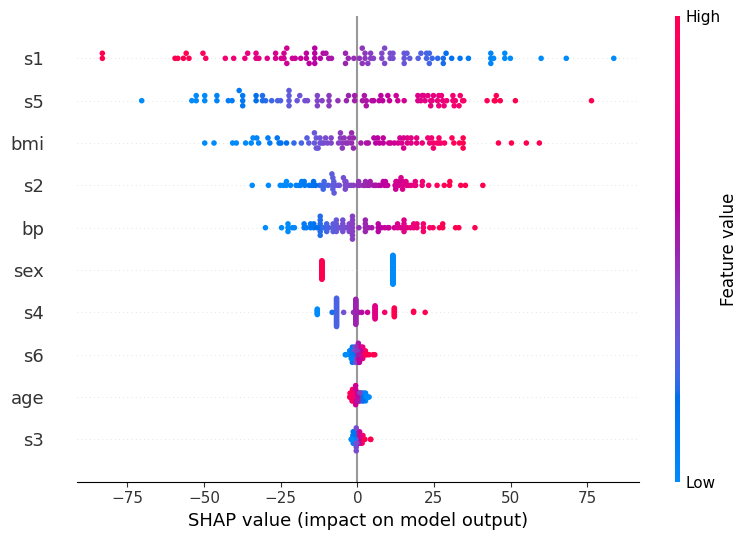

In [48]:
shap.initjs()
shap_values = ex.shap_values(X_test)
shap.summary_plot(shap_values, X_test)

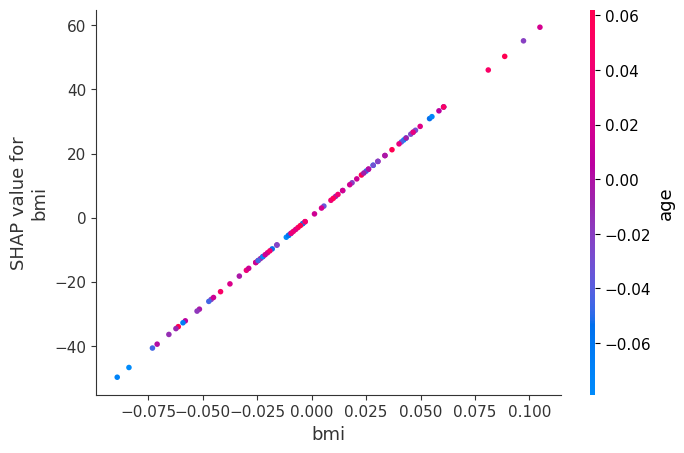

In [49]:
shap.initjs()
shap.dependence_plot("bmi", shap_values, X_test)

In [50]:
shap.initjs()
shap.force_plot(ex.expected_value, shap_values, X_test)


Root mean squared test error = 69.15453208861445


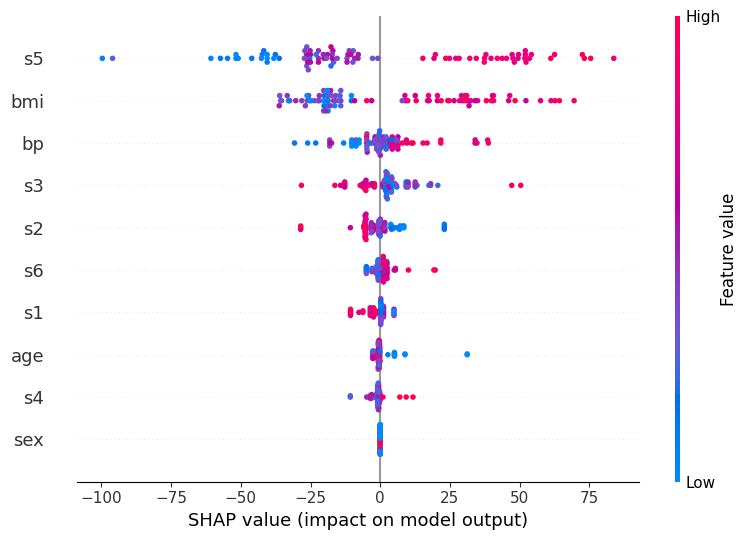

In [65]:
from sklearn import tree

dtree = tree.DecisionTreeRegressor(max_depth=5)
dtree.fit(X_train, y_train)
print_accuracy(dtree.predict)

# explain all the predictions in the test set
ex = shap.TreeExplainer(dtree)
shap_values = ex.shap_values(X_test)
shap.summary_plot(shap_values, X_test)

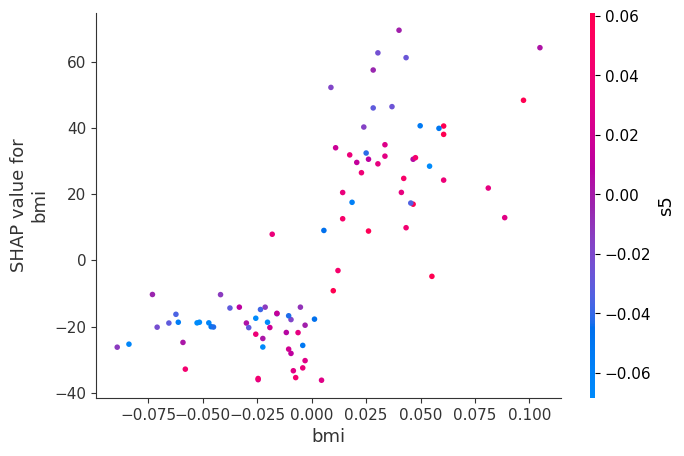

In [66]:
shap.initjs()
shap.dependence_plot("bmi", shap_values, X_test)


In [67]:
shap.initjs()
shap.force_plot(ex.expected_value, shap_values, X_test)



/usr/local/lib/python3.10/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:545: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


Root mean squared test error = 58.230396692749125


  0%|          | 0/89 [00:00<?, ?it/s]

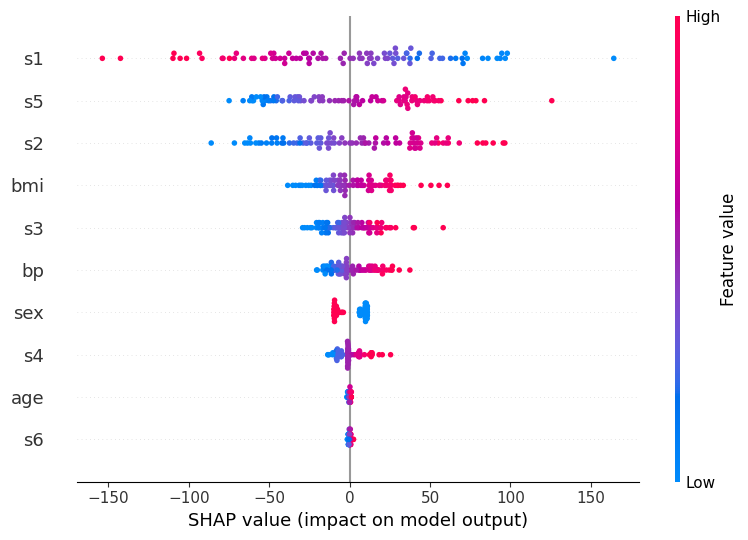

In [68]:
from sklearn.neural_network import MLPRegressor

nn = MLPRegressor(solver="lbfgs", alpha=1e-1, hidden_layer_sizes=(5, 2), random_state=0)
nn.fit(X_train, y_train)
print_accuracy(nn.predict)

# explain all the predictions in the test set
explainer = shap.KernelExplainer(nn.predict, X_train_summary)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)

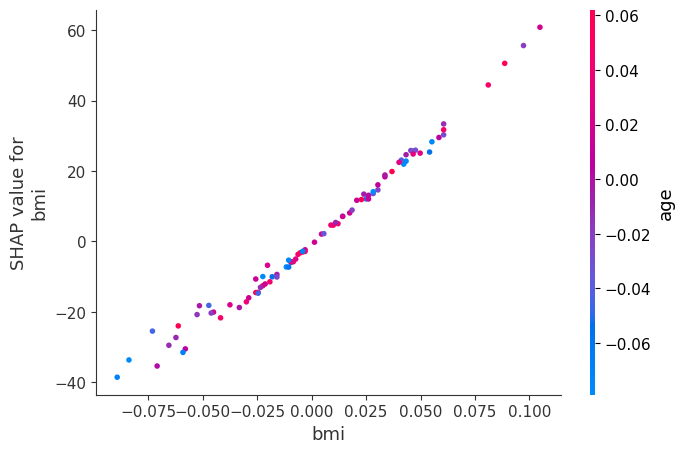

In [69]:
shap.initjs()
shap.dependence_plot("bmi", shap_values, X_test)


In [70]:
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values, X_test)
